In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import scipy
import scipy.signal as signal
import pickle as pkl
from collections import OrderedDict

import Utils as fx

import matplotlib.patches as patches
from PIL import Image

import powerlaw as plaw

from IPython.core.display import display, HTML
display(HTML('<style>.container {width:100% !important;}</style>'))

/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/4154294492.py:17: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


## Fot the analysis, data was stored as a dictionary:  
Spikes["Right_H"]["spiketime"], Spikes["Right_H"]["neuronid"].   
Spikes["Left_H"]["spiketime"], Spikes["Left_H"]["neuronid"]

<IPython.core.display.Javascript object>


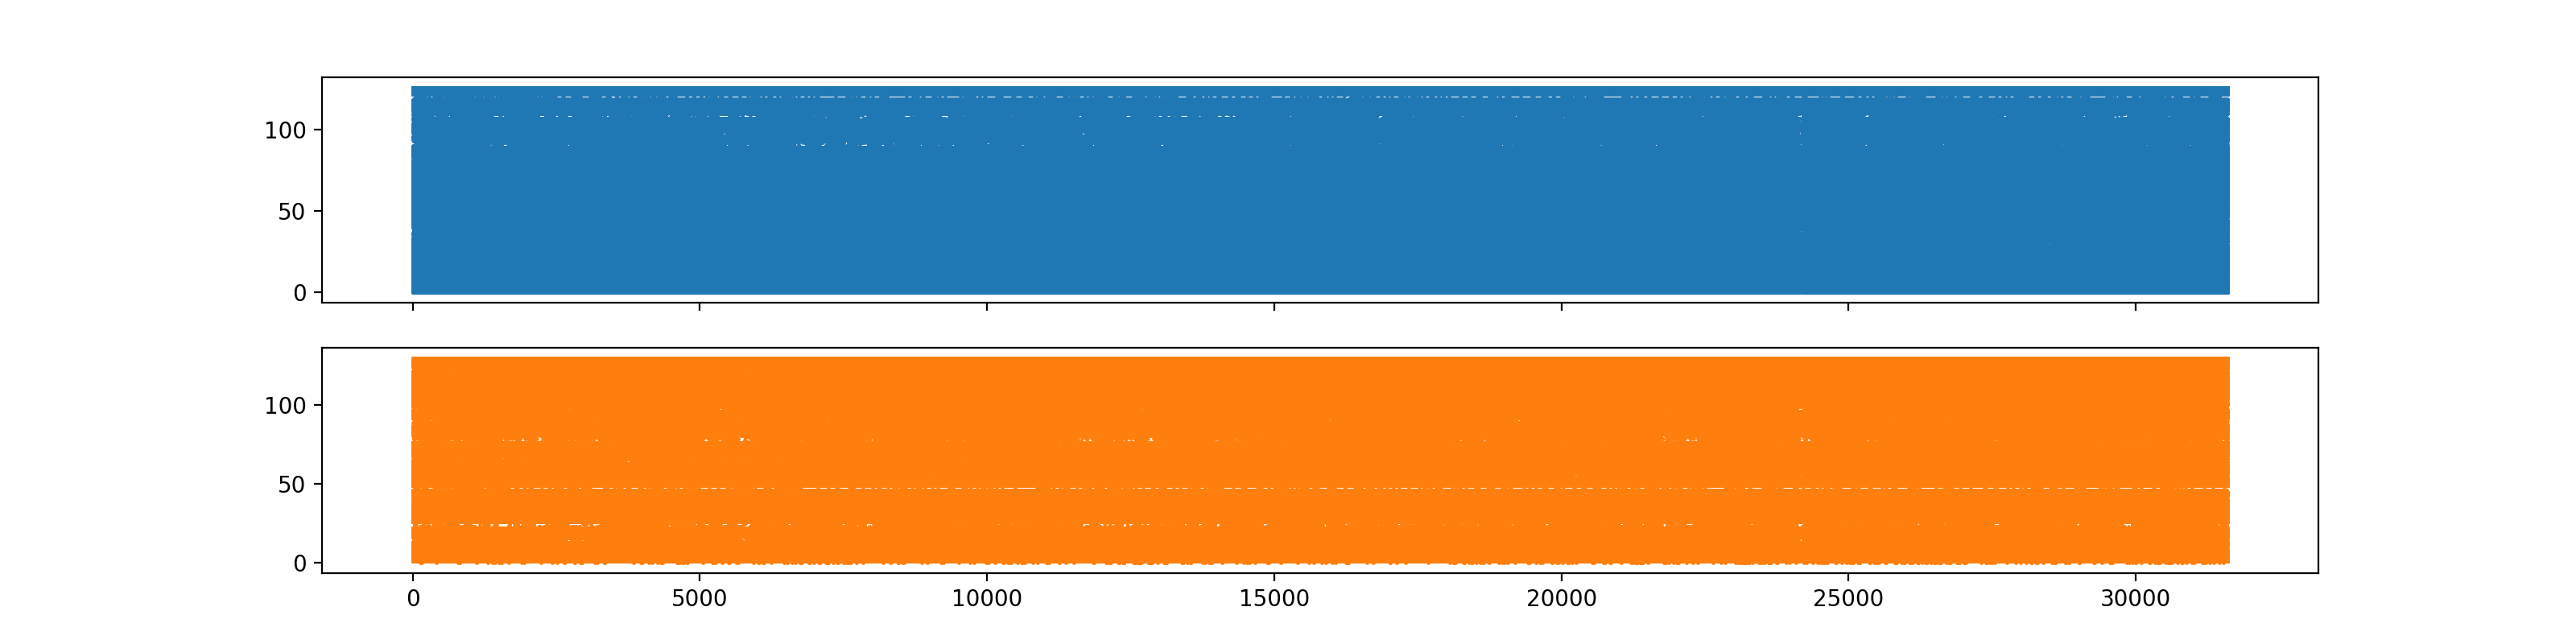

In [ ]:
fig, axs = plt.subplots(nrows=2, figsize=(16,4), sharex = True)
axs[0].scatter(Spikes["Right_H"]["spiketime"], Spikes["Right_H"]["neuronid"], s = 0.5, c = 'tab:blue')
axs[1].scatter(Spikes["Left_H"]["spiketime"], Spikes["Left_H"]["neuronid"], s = 0.5, c = 'tab:orange')
plt.show()

Create Matrix of FR

In [15]:
# # Initialize Kernel
kern = fx.get_mexican_hat_kernel(T = 0.01, J = None) # see Fontenele PRL
# # deltaT (bin size) for FR
deltaT = 20e-3 # FREE PARAMETER

firstbin = np.min(Spikes["Right_H"]["spiketime"])
lastbin = np.max(Spikes["Right_H"]["spiketime"])

numpoints = int(lastbin / deltaT - firstbin / deltaT)

BinsFR = np.linspace(np.min(Spikes["Right_H"]["spiketime"]), np.max(Spikes["Right_H"]["spiketime"]), num = numpoints)
FRtime = np.arange(firstbin, lastbin, (lastbin-firstbin) / (numpoints-1))

w, h = numpoints, int(np.max(Spikes["Right_H"]["neuronid"]));
Matrix_right = [[0 for x in range(w)] for y in range(h)] 


firstbin = np.min(Spikes["Left_H"]["spiketime"])
lastbin = np.max(Spikes["Left_H"]["spiketime"])

numpoints = int(lastbin / deltaT - firstbin / deltaT)

BinsFR = np.linspace(np.min(Spikes["Left_H"]["spiketime"]), np.max(Spikes["Left_H"]["spiketime"]), num = numpoints)
FRtime = np.arange(firstbin, lastbin, (lastbin-firstbin) / (numpoints-1))

w, h = numpoints, int(np.max(Spikes["Left_H"]["neuronid"]));
Matrix_left = [[0 for x in range(w)] for y in range(h)] 

In [16]:
# Fulfill the matrix with convolved FR, i.e., from discrete spikes to continuum convolved spks.
for i in range(0, int(np.max(Spikes["Right_H"]["neuronid"]))):
    Neuron = Spikes["Right_H"]["spiketime"][Spikes["Right_H"]["neuronid"] == i]
    FR_neuron, _ = np.histogram(Neuron, bins = BinsFR, density=False)
    FR_conv = np.convolve(FR_neuron, kern, 'same')
    
    Matrix_right[i][:] = FR_conv
    
Matrix_right = np.asarray(Matrix_right)

# Fulfill the matrix with convolved FR
for i in range(0, int(np.max(Spikes["Left_H"]["neuronid"]))):
    Neuron = Spikes["Left_H"]["spiketime"][Spikes["Left_H"]["neuronid"] == i]
    FR_neuron, _ = np.histogram(Neuron, bins = BinsFR, density=False)
    FR_conv = np.convolve(FR_neuron, kern, 'same')
    
    Matrix_left[i][:] = FR_conv

    
Matrix_left = np.asarray(Matrix_left)


# Compute correlations over windows

In [17]:
deltaT = 5 # FREE PARAMETER in units of the data

numiterations= int((lastbin - firstbin) / deltaT)

timeforcorr = np.linspace(firstbin, lastbin, numiterations-1)


meanCorr_right = []
meanCorr_left = []
meanXCorr = []

for t in range(0,numiterations-1):
    idx = np.where((FRtime > firstbin + deltaT * t) & (FRtime < (firstbin + deltaT * (t + 1))))[0]

    data1 = Matrix_right[:,idx]
    data2 = Matrix_left[:,idx]
    
    CorrelationMatrix = []
    ##Corr Local RIGHT
    CorrelationMatrix = fx.corr2_coeff(data1, data1)
    CorrelationMatrix[CorrelationMatrix >= 0.99] = np.NaN 
    meanCorr_right.append(np.nanmean(CorrelationMatrix))
    
    CorrelationMatrix = []
    ##Corr Local LEFT
    CorrelationMatrix = fx.corr2_coeff(data2, data2)
    CorrelationMatrix[CorrelationMatrix >= 0.99] = np.NaN 
    meanCorr_left.append(np.nanmean(CorrelationMatrix))
    

    CorrelationMatrix = []    
    ##Cross Corr RIGHT-LEFT
    CorrelationMatrix = fx.corr2_coeff(data1, data2)
    CorrelationMatrix[CorrelationMatrix >= 0.99] = np.NaN 
    meanXCorr.append(np.nanmean(CorrelationMatrix))

/Users/ldallap/Library/CloudStorage/Dropbox/CollabRabuffo/WorkingArea/Utils.py:135: RuntimeWarning: invalid value encountered in divide
  return np.dot(A_mA, B_mB.T) / np.sqrt(np.dot(ssA[:, None],ssB[None]))
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/635030943.py:22: RuntimeWarning: Mean of empty slice
  meanCorr_right.append(np.nanmean(CorrelationMatrix))
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/635030943.py:28: RuntimeWarning: Mean of empty slice
  meanCorr_left.append(np.nanmean(CorrelationMatrix))
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/635030943.py:35: RuntimeWarning: Mean of empty slice
  meanXCorr.append(np.nanmean(CorrelationMatrix))


## Avalanches for Size and Duration as stored like: 
spikes_by_corr_SIZE_right.  
spikes_by_corr_DUR_right

In [ ]:
numCorrbins = 30 # FREE PARAMETER

mincorr = -0.01
maxcorr = 0.20
bins2use_hist = np.linspace(mincorr,maxcorr,numCorrbins)


histCorr_right, binsCorr_right = np.histogram(np.asarray(meanCorr_right), bins = bins2use_hist, density = False)
histCorr_left, binsCorr_left = np.histogram(np.asarray(meanCorr_left), bins = bins2use_hist, density = False)

bins_conc_time=np.arange(timeforcorr[0],24120,(24120-timeforcorr[0])/numCorrbins)

spikes_by_corr_SIZE_left=[[] for i in range(numCorrbins)]
spikes_by_corr_DUR_left=[[] for i in range(numCorrbins)]

spikes_by_corr_SIZE_right=[[] for i in range(numCorrbins)]
spikes_by_corr_DUR_right=[[] for i in range(numCorrbins)]

mean_corr_bin = []

for k in range(len(binsCorr_left)-1):
    auxL1=[]
    for i in range(len(meanCorr_left)):
        if(meanCorr_left[i] >= binsCorr_left[k] and meanCorr_left[i] <= binsCorr_left[k+1]):
            auxL1.append(meanCorr_left[i])
            
    mean_corr_bin.append(np.mean(auxL1))

In [21]:
datatouse = Spikes["Left_H"]["spiketime"]
mintime = np.min(datatouse)
maxtime = np.max(datatouse)


meanCorr = meanCorr_left
binsCorr = binsCorr_left
###
for k in range(len(binsCorr)-1):
# for k in [5]:
    TimeBinAva=0
    # whereCorr_start will store the times in which correlations occur
    # whereCorr_end will store the times in which correlations occur
    # First detect where in time do we have groups of corr similar spks
    idx = np.where((meanCorr >= binsCorr[k]) & (meanCorr < binsCorr[k+1]))[0]
    whereCorr_start = timeforcorr[idx] # it is just the start of a given corr
    whereCorr_end = whereCorr_start + deltaT # it is just the end of a given corr that has the lenght of deltaT 
    ###(whereCorr_end[i] - whereCorr_start[i]) marks the period in time where a given correlaiton occurs
    

    #Now we need to look to those intervals stored in whereCV
    #compute the neuronal avalanches and then concatenate
    for w in range(0,len(whereCorr_start)):
        
        idxs_corr = np.where((datatouse >= whereCorr_start[w]) & (datatouse < whereCorr_end[w]))[0]
        spikes_corr_aux = datatouse[idxs_corr].copy()

        auxlistspks=spikes_corr_aux.copy()
        listspks=sorted(set(auxlistspks.copy())) #remove equal values !!!!!
        TimeBinAva=(np.mean(np.diff(listspks.copy())))
        TimeBinAva=1.*float(TimeBinAva)
        bindtAtimeforcorr=np.linspace(mintime,maxtime,numiterations-1)
        bindtAvalanche=TimeBinAva

        #Now Compute neuronal avalanches using TimeBinAva
        #First construct the bins to look at
        if(len(spikes_corr_aux) > 10):
        
            firstbin1=np.min(spikes_corr_aux)
            lastbin1=np.max(spikes_corr_aux)

            numpoints=int((lastbin1/bindtAvalanche)-(firstbin1/bindtAvalanche))
            bin_position1=[]
            for kk in range(0,numpoints):
                bin_position1.append(float(firstbin1+(TimeBinAva*kk)))
            #Now we compute the histogram and then the neuronal avalanches and save
            avasize,aux = np.histogram(spikes_corr_aux,bins=bin_position1,density=False)
            #Avalanches Size and Duration
            durattot = []
            avasizetot = []
            auxsum = 0
            auxdur = 0
            if(len(avasize)>2):
                for i, val in enumerate(avasize[np.where(avasize!=0)[0][0]:]):
                    if val != 0:
                        auxsum += val
                        auxdur += 1
                    if val == 0 and avasize[i-1]!=0:
                        avasizetot.append(auxsum)
                        durattot.append(auxdur)
                        auxsum=0
                        auxdur=0
    #             print(avasizetot)
    #             print(durattot)
    #             print(bindtAvalanche)
    #             break
            spikes_by_corr_SIZE_left[k]=spikes_by_corr_SIZE_left[k]+avasizetot
            spikes_by_corr_DUR_left[k]=spikes_by_corr_DUR_left[k]+durattot

/Users/ldallap/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ldallap/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
datatouse = Spikes["Right_H"]["spiketime"]
mintime = np.min(datatouse)
maxtime = np.max(datatouse)

meanCorr = meanCorr_right
binsCorr = binsCorr_right
###
for k in range(len(binsCorr)-1):
# for k in [5]:
    TimeBinAva=0
    # whereCorr_start will store the times in which correlations occur
    # whereCorr_end will store the times in which correlations occur
    # First detect where in time do we have groups of corr similar spks
    idx = np.where((meanCorr >= binsCorr[k]) & (meanCorr < binsCorr[k+1]))[0]
    whereCorr_start = timeforcorr[idx] # it is just the start of a given corr
    whereCorr_end = whereCorr_start + deltaT # it is just the end of a given corr that has the lenght of deltaT 
    ###(whereCorr_end[i] - whereCorr_start[i]) marks the period in time where a given correlaiton occurs
    

    #Now we need to look to those intervals stored in whereCV
    #compute the neuronal avalanches and then concatenate
    for w in range(0,len(whereCorr_start)):
        
        idxs_corr = np.where((datatouse >= whereCorr_start[w]) & (datatouse < whereCorr_end[w]))[0]
        spikes_corr_aux = datatouse[idxs_corr]

        auxlistspks=spikes_corr_aux.copy()
        listspks=sorted(set(auxlistspks)) #remove equal values !!!!!
        TimeBinAva=(np.mean(np.diff(listspks.copy())))
        TimeBinAva=1.*float(TimeBinAva)
        bindtAtimeforcorr=np.linspace(mintime,maxtime,numiterations-1)
        bindtAvalanche=TimeBinAva

        #Now Compute neuronal avalanches using TimeBinAva
        #First construct the bins to look at
        if(len(spikes_corr_aux) >= 10):
        
            firstbin1=np.min(spikes_corr_aux)
            lastbin1=np.max(spikes_corr_aux)

            numpoints=int((lastbin1/bindtAvalanche)-(firstbin1/bindtAvalanche))
            bin_position1=[]
            for kk in range(0,numpoints):
                bin_position1.append(float(firstbin1+(TimeBinAva*kk)))

            #Now we compute the histogram and then the neuronal avalanches and save
            avasize,aux = np.histogram(spikes_corr_aux,bins=bin_position1,density=False)
            #Avalanches Size and Duration
            durattot = []
            avasizetot = []
            auxsum = 0
            auxdur = 0
            if(len(avasize)>2):
                for i, val in enumerate(avasize[np.where(avasize!=0)[0][0]:]):
                    if val != 0:
                        auxsum += val
                        auxdur += 1
                    if val == 0 and avasize[i-1]!=0:
                        avasizetot.append(auxsum)
                        durattot.append(auxdur)
                        auxsum=0
                        auxdur=0
    #             print(avasizetot)
    #             print(durattot)
    #             print(bindtAvalanche)
    #             break
            spikes_by_corr_SIZE_right[k]=spikes_by_corr_SIZE_right[k]+avasizetot
            spikes_by_corr_DUR_right[k]=spikes_by_corr_DUR_right[k]+durattot

/Users/ldallap/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ldallap/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<IPython.core.display.Javascript object>


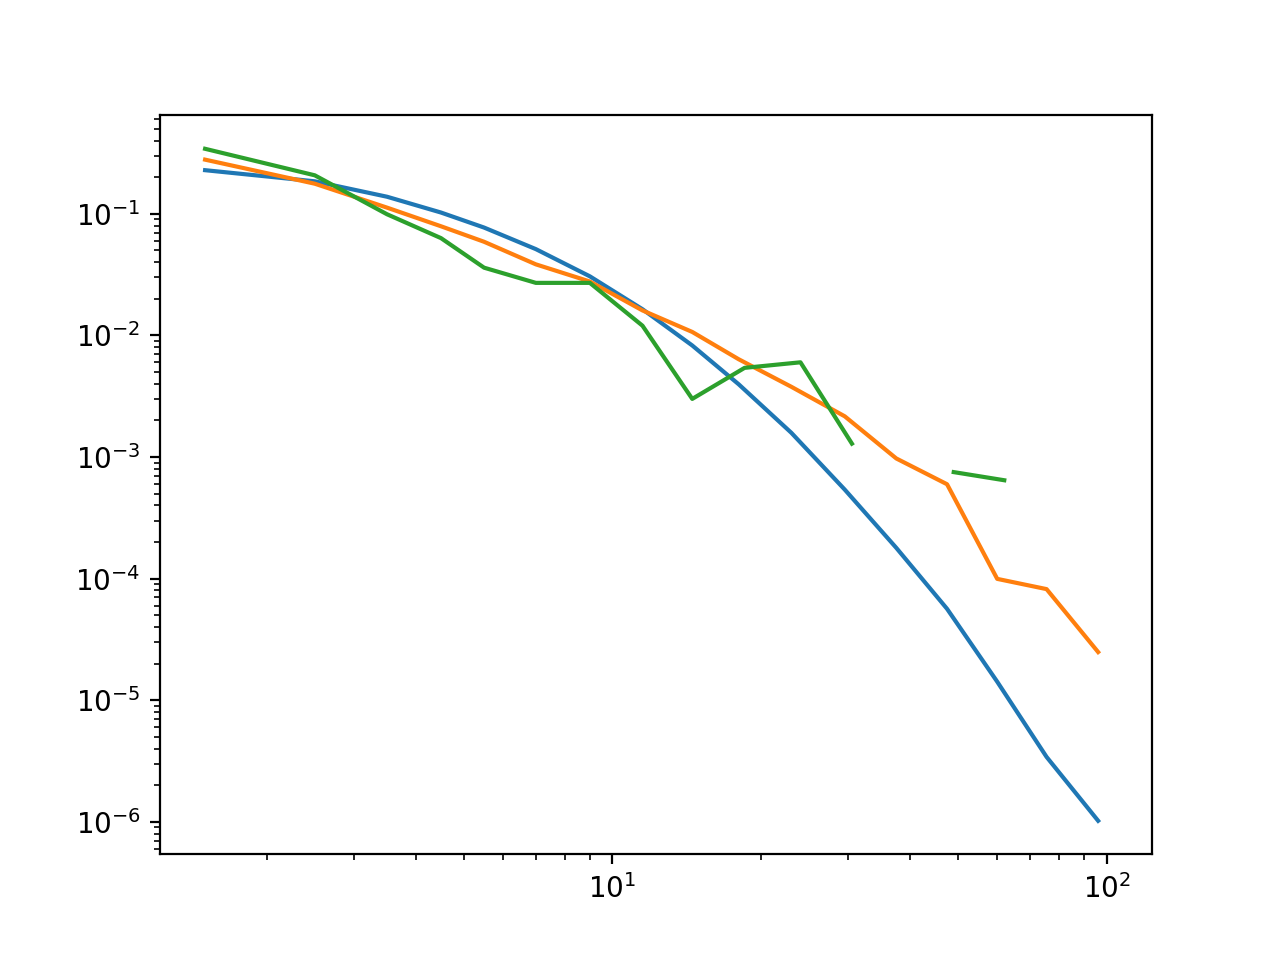

In [ ]:
# Plot the distribution
plt.figure()
for i in [2,15,25]:
    fx.plot_pdf(spikes_by_corr_SIZE_right[i])
plt.show()

In [24]:
Size_DUR_L = [[] for i in range(numCorrbins)]
Size_DUR_R  = [[] for i in range(numCorrbins)]

DUR_L = [[] for i in range(numCorrbins)]
DUR_R  = [[] for i in range(numCorrbins)]

for jj in range(numCorrbins):
    if(len(spikes_by_corr_SIZE_left[jj])):
        AllpossibleDUR_L = []
        AllpossibleDUR_L = list(OrderedDict.fromkeys(spikes_by_corr_DUR_left[jj]))
        AllpossibleDUR_L.sort()
        
        for i in AllpossibleDUR_L:
            sumSize = 0
            n_occur_dur = 0
            idxs = (np.where(np.asarray(spikes_by_corr_DUR_left[jj]) == i)[0])
            n_occur_dur = len(idxs)
            sumSize = np.mean(np.asarray(spikes_by_corr_SIZE_left[jj])[idxs])
            Size_DUR_L[jj].append(sumSize)
            DUR_L[jj].append(i)

    if(len(spikes_by_corr_SIZE_right[jj])):
        AllpossibleDUR_R = []
        AllpossibleDUR_R = list(OrderedDict.fromkeys(spikes_by_corr_DUR_right[jj]))
        AllpossibleDUR_R.sort()
        AllpossibleDUR_R = list(np.around(np.array(AllpossibleDUR_R),4))
        
        for i in AllpossibleDUR_R:
            sumSize = 0
            n_occur_dur = 0
            idxs = (np.where(np.round(np.asarray(spikes_by_corr_DUR_right[jj]),4) == i)[0])
            n_occur_dur = len(idxs)
            sumSize = np.mean(np.asarray(spikes_by_corr_SIZE_right[jj])[idxs])
            Size_DUR_R[jj].append(sumSize)
            DUR_R[jj].append(i)

In [26]:
sigmanuz_left = []
sigmanuz_right = []


x2 = []
y2 = []

x3 = []
y3 = []

for idx in range(0,21):
# for idx in [4]:

    xminfit = 3 # must be equal of the one used in the pwlaw range fit
    xmaxfit = 32

    x1 = []
    y1 = []
 
    for i in range(len(DUR_R[idx])):
        if(DUR_R[idx][i]>=xminfit and DUR_R[idx][i]<=xmaxfit):
            x1.append(DUR_R[idx][i])
            y1.append(Size_DUR_R[idx][i])

    x1 = np.log10(np.asarray(x1))
    y1 = np.log10(np.asarray(y1))

    m,b = np.polyfit(x1,y1,1)
    sigmanuz_right.append(m)
    print(idx, m)
    
    if idx == 16:
        x2 = x1.copy()
        y2 = y1.copy()
    
    x1 = []
    y1 = []
    for i in range(len(DUR_L[idx])):
        if(DUR_L[idx][i]>=xminfit and DUR_L[idx][i]<=xmaxfit):
            x1.append(DUR_L[idx][i])
            y1.append(Size_DUR_L[idx][i])

    x1 = np.log10(np.asarray(x1))
    y1 = np.log10(np.asarray(y1))
    
    if idx == 16:
        x3 = x1.copy()
        y3 = y1.copy()

    m,b = np.polyfit(x1,y1,1)
    sigmanuz_left.append(m)

    print(idx, m)

0 1.1210998937616283
0 1.075554631370962
1 1.0945848174929298
1 1.1167256362818287
2 1.1181395142770798
2 1.144561544409388
3 1.1448681525521782
3 1.1774274953605472
4 1.1598932214549784
4 1.1893819652384703
5 1.1708014798829713
5 1.1978454452950733
6 1.1511052447349308
6 1.195836698367741
7 1.157764208983806
7 1.203519585319933
8 1.1726770612843525
8 1.187824672086314
9 1.1820514216524682
9 1.204454322495419
10 1.1803748822918827
10 1.1769860255706466
11 1.1645420932436183
11 1.2047358142210838
12 1.1561476372141128
12 1.2160327989993667
13 1.1221035988779693
13 1.2097578648156648
14 1.1703212948339359
14 1.1906442863075466
15 1.192950300202072
15 1.1873157528583593
16 1.1546947008466357
16 1.2128577021241391
17 1.2018303589599826
17 1.178176499499032
18 1.2216406000161193
18 1.219900689864039
19 1.1773523584635133
19 1.2083573874831395
20 1.2611058337234151
20 1.185616249669746


In [34]:
taurelation_right = []
taurelation_left = []

for i in range(0,30):
    a,b = fx.mle(spikes_by_corr_SIZE_right[i], xmin =3, xmax =32)
    c,b = fx.mle(spikes_by_corr_DUR_right[i], xmin =2, xmax =18)
    print(i,a,c, (c-1)/(a-1))#|
    taurelation_right.append((c-1)/(a-1))
print("\n")
for i in range(0,30):
    a,b = fx.mle(spikes_by_corr_SIZE_left[i], xmin =3, xmax =32)
    c,b = fx.mle(spikes_by_corr_DUR_left[i], xmin =2, xmax =18)
    print(i,a,c, (c-1)/(a-1))#|
    taurelation_left.append((c-1)/(a-1))

0 2.0139999999999993 2.064999999999999 1.0502958579881654
1 2.0119999999999996 2.072999999999998 1.0602766798418959
2 1.988 2.0529999999999986 1.065789473684209
3 1.958 2.0329999999999995 1.0782881002087679
4 1.9009999999999996 1.9960000000000002 1.1054384017758054
5 1.846 1.9539999999999993 1.1276595744680842
6 1.7819999999999994 1.907 1.159846547314579
7 1.7599999999999996 1.8899999999999997 1.1710526315789476
8 1.7329999999999992 1.8709999999999996 1.1882673942701234
9 1.693999999999999 1.8409999999999995 1.2118155619596551
10 1.6869999999999998 1.8289999999999997 1.2066957787481805
11 1.6629999999999991 1.807 1.217194570135748
12 1.6799999999999995 1.8139999999999992 1.1970588235294115
13 1.675 1.8239999999999992 1.2207407407407393
14 1.6059999999999999 1.784999999999999 1.295379537953794
15 1.6609999999999994 1.807 1.2208774583963702
16 1.6409999999999993 1.7829999999999993 1.2215288611544461
17 1.6589999999999996 1.784999999999999 1.191198786039453
18 1.6479999999999997 1.7689999

/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/3451667222.py:7: RuntimeWarning: invalid value encountered in scalar divide
  print(i,a,c, (c-1)/(a-1))#|
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/3451667222.py:8: RuntimeWarning: invalid value encountered in scalar divide
  taurelation_right.append((c-1)/(a-1))
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/3451667222.py:13: RuntimeWarning: invalid value encountered in scalar divide
  print(i,a,c, (c-1)/(a-1))#|
/var/folders/nk/jbpc1ff56bz7kchlrqyzt9z80000gn/T/ipykernel_25946/3451667222.py:14: RuntimeWarning: invalid value encountered in scalar divide
  taurelation_left.append((c-1)/(a-1))


In [35]:
sigmanuz_left = []
sigmanuz_right = []


x2 = []
y2 = []

x3 = []
y3 = []

for idx in range(0,30):
# for idx in [4]:

    xminfit = 3 # must be equal of the one used in the pwlaw range fit
    xmaxfit = 32

    x1 = []
    y1 = []
 
    for i in range(len(DUR_R[idx])):
        if(DUR_R[idx][i]>=xminfit and DUR_R[idx][i]<=xmaxfit):
            x1.append(DUR_R[idx][i])
            y1.append(Size_DUR_R[idx][i])

    x1 = np.log10(np.asarray(x1))
    y1 = np.log10(np.asarray(y1))

    m,b = np.polyfit(x1,y1,1)
    sigmanuz_right.append(m)
    print(idx, m)
    
    if idx == 16:
        x2 = x1.copy()
        y2 = y1.copy()
    
    x1 = []
    y1 = []
    for i in range(len(DUR_L[idx])):
        if(DUR_L[idx][i]>=xminfit and DUR_L[idx][i]<=xmaxfit):
            x1.append(DUR_L[idx][i])
            y1.append(Size_DUR_L[idx][i])

    x1 = np.log10(np.asarray(x1))
    y1 = np.log10(np.asarray(y1))
    
    if idx == 16:
        x3 = x1.copy()
        y3 = y1.copy()

    m,b = np.polyfit(x1,y1,1)
    sigmanuz_left.append(m)

    print(idx, m)

0 1.1210998937616283
0 1.075554631370962
1 1.0945848174929298
1 1.1167256362818287
2 1.1181395142770798
2 1.144561544409388
3 1.1448681525521782
3 1.1774274953605472
4 1.1598932214549784
4 1.1893819652384703
5 1.1708014798829713
5 1.1978454452950733
6 1.1511052447349308
6 1.195836698367741
7 1.157764208983806
7 1.203519585319933
8 1.1726770612843525
8 1.187824672086314
9 1.1820514216524682
9 1.204454322495419
10 1.1803748822918827
10 1.1769860255706466
11 1.1645420932436183
11 1.2047358142210838
12 1.1561476372141128
12 1.2160327989993667
13 1.1221035988779693
13 1.2097578648156648
14 1.1703212948339359
14 1.1906442863075466
15 1.192950300202072
15 1.1873157528583593
16 1.1546947008466357
16 1.2128577021241391
17 1.2018303589599826
17 1.178176499499032
18 1.2216406000161193
18 1.219900689864039
19 1.1773523584635133
19 1.2083573874831395
20 1.2611058337234151
20 1.185616249669746
21 1.1318609861480402
21 1.223619239651627


TypeError: expected non-empty vector for x

In [66]:
taurelation_right = []
taurelation_left = []

for i in range(0,21):
    a,b = fx.mle(spikes_by_corr_SIZE_right[i], xmin =3, xmax =40)
    c,b = fx.mle(spikes_by_corr_DUR_right[i], xmin =2, xmax = 18)
    print(i,a,c, (c-1)/(a-1))#|
    taurelation_right.append((c-1)/(a-1))
print("\n")
for i in range(0,21):
    a,b = fx.mle(spikes_by_corr_SIZE_left[i], xmin =3, xmax = 32)
    c,b = fx.mle(spikes_by_corr_DUR_left[i], xmin =2, xmax = 18)
    print(i,a,c, (c-1)/(a-1))#|
    taurelation_left.append((c-1)/(a-1))



# taurelation_left
# taurelation_right
# sigmanuz_left
# sigmanuz_right

DCC_left = []
for i in range(len(taurelation_left)):
    print(i, taurelation_left[i]-sigmanuz_left[i])
    DCC_left.append(taurelation_left[i]-sigmanuz_left[i])
    

DCC_right = []
for i in range(len(taurelation_right)):
    print(i, taurelation_right[i]-sigmanuz_right[i])
    DCC_right.append(taurelation_right[i]-sigmanuz_right[i])

0 2.0759999999999987 2.064999999999999 0.9897769516728627
1 2.072999999999998 2.072999999999998 1.0
2 2.049 2.0529999999999986 1.0038131553860807
3 2.015 2.0329999999999995 1.0177339901477827
4 1.9589999999999999 1.9960000000000002 1.0385818561001046
5 1.898 1.9539999999999993 1.0623608017817365
6 1.827 1.907 1.0967351874244258
7 1.8079999999999998 1.8899999999999997 1.1014851485148514
8 1.7779999999999998 1.8709999999999996 1.1195372750642671
9 1.7379999999999998 1.8409999999999995 1.1395663956639563
10 1.7269999999999999 1.8289999999999997 1.140302613480055
11 1.7069999999999999 1.807 1.1414427157001417
12 1.716 1.8139999999999992 1.1368715083798873
13 1.714999999999999 1.8239999999999992 1.152447552447553
14 1.646 1.784999999999999 1.2151702786377696
15 1.7079999999999997 1.807 1.1398305084745766
16 1.673999999999999 1.7829999999999993 1.1617210682492587
17 1.7029999999999992 1.784999999999999 1.1166429587482218
18 1.695 1.7689999999999997 1.1064748201438843
19 1.8109999999999995 1.

<IPython.core.display.Javascript object>


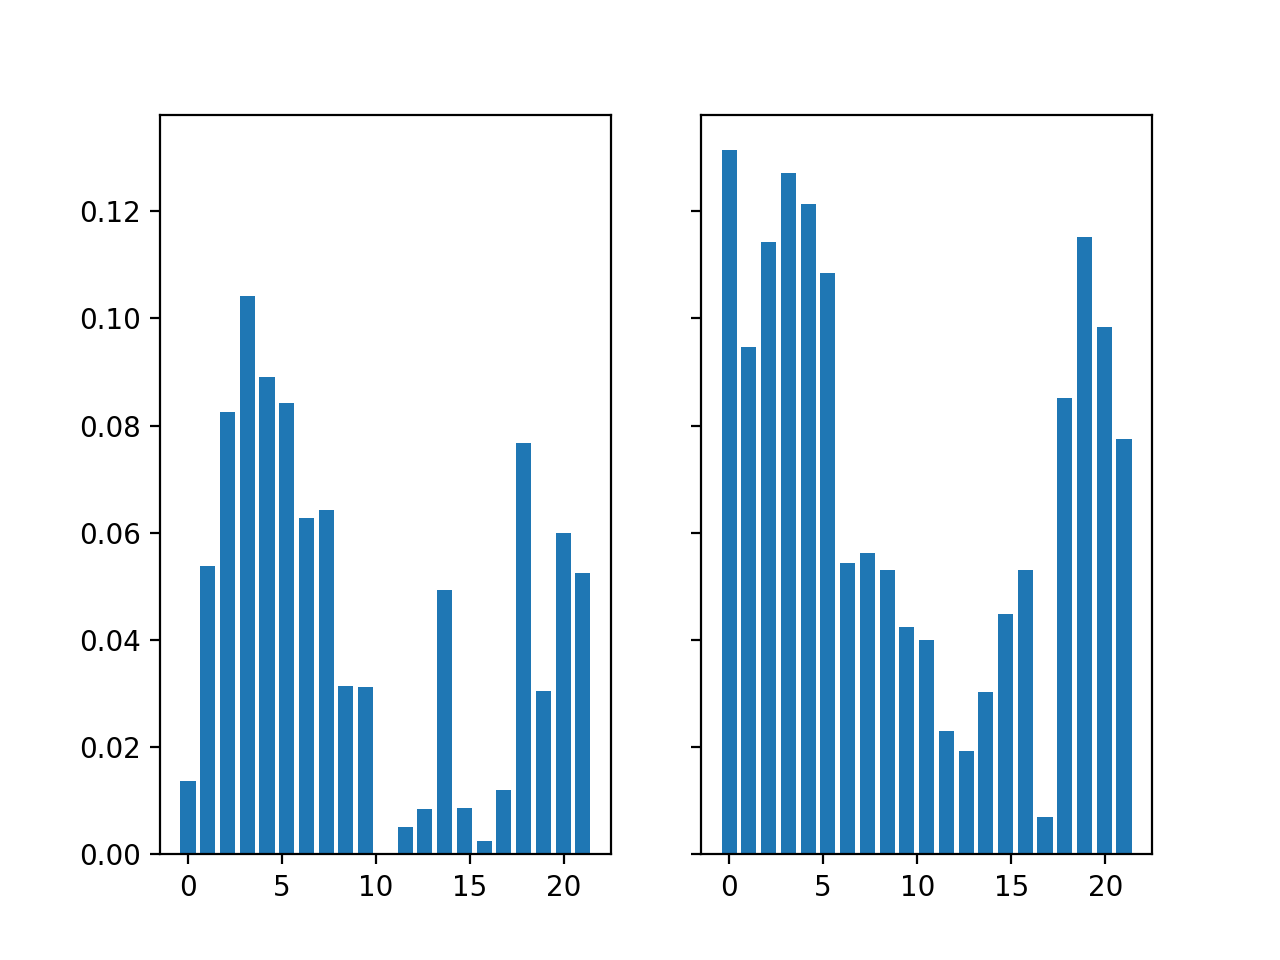

In [67]:
fig, axs = plt.subplots(ncols=2, sharey=True)

axs[0].bar(np.linspace(0,len(DCC_left),len(DCC_left)), np.abs(DCC_left))

axs[1].bar(np.linspace(0,len(DCC_right),len(DCC_right)), np.abs(DCC_right))

plt.show()